# ShopSmart: Purchase Prediction Using Decision Trees

**Objective:** Predict whether a customer will generate revenue (make a purchase) based on their browsing behaviour and session data from an e-commerce platform.

**Approach:** Build a Decision Tree classifier and optimise it using pre-pruning and post-pruning techniques to improve generalisation.

**Dataset:** `shop_smart_ecommerce.csv`

**Metric Used:** F1-Score (chosen due to class imbalance between buyers and non-buyers)

## 1. Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

Inspect the column types, null values, and basic structure of the dataset.

In [3]:
df.info() #Montha and visitor are in categories

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 3.2 Class Distribution — Revenue

Checking for class imbalance. An imbalanced target variable means accuracy alone is misleading — hence F1-Score is used.

Text(0.5, 1.0, 'Is Revenue genereated?')

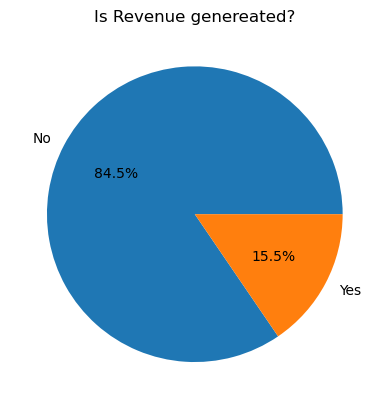

In [5]:
#How balanced our output classes?

class_cnt = df["Revenue"].value_counts()
plt.pie(class_cnt, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is Revenue genereated?")

### 3.3 Visitor Type Distribution

Most users are returning visitors. This feature will be one-hot encoded before training.

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

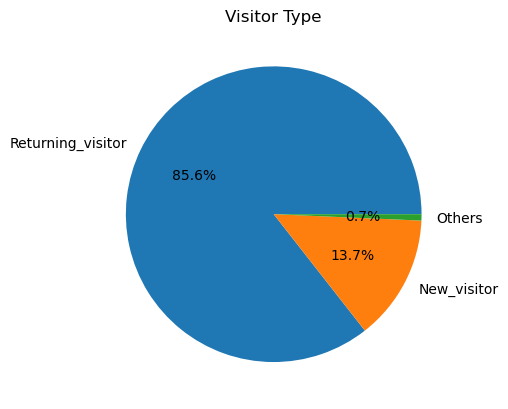

In [6]:
#checking distributions of all categorical features

class_cnt = df["VisitorType"].value_counts()
plt.pie(class_cnt,labels=["Returning_visitor","New_visitor","Others"], autopct="%1.1f%%")
plt.title("Visitor Type")
class_cnt

### 3.4 Monthly Revenue Distribution

Revenue activity peaks in November — likely driven by Black Friday / Diwali sales. No data exists for January and April.

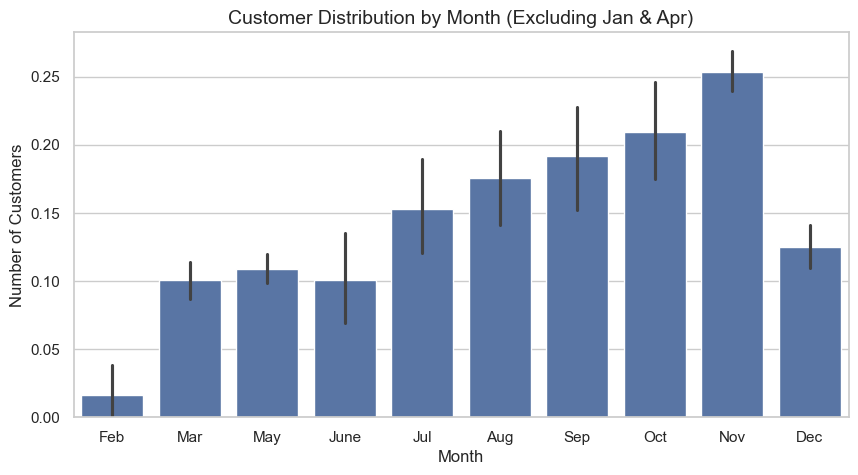

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Define the correct chronological order for 10 existing months
month_order = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]

# 2. Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 3. Bar chart with the forced 'order' parameter
sns.barplot(
    data=df, x="Month", y="Revenue", order=month_order, color="b"
)

# 4. Clean up the labels
plt.title("Customer Distribution by Month (Excluding Jan & Apr)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()


## 4. Data Preprocessing

### 4.1 Encoding Categorical Features

- `Revenue` and `Weekend` are label-encoded (binary).
- `VisitorType` and `Month` are one-hot encoded with `drop_first=True` to avoid multicollinearity.

In [8]:
#Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Revenue"] = le.fit_transform(df["Revenue"])
df["Weekend"] = le.fit_transform(df["Weekend"])

df = pd.get_dummies(df,columns = ["VisitorType"],drop_first=True,dtype=int)
df = pd.get_dummies(df,columns = ["Month"],drop_first = True,dtype=int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

## 5. Baseline Decision Tree Model

### 5.1 Train-Test Split

Split data into 80% training and 20% testing. `random_state=42` ensures reproducibility.

In [10]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,precision_score,accuracy_score,recall_score

X = df.drop("Revenue",axis=1)
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y , test_size=0.2, random_state=42
)

### 5.2 Training the Baseline Model

Train an unpruned Decision Tree with default hyperparameters. This will likely overfit.

In [11]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 5.3 Baseline Model Evaluation

Evaluate on the test set. Low F1-Score expected due to overfitting on the training data.

In [12]:
y_pred = model.predict(X_test)

print("F1 score: ",f1_score(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))


F1 score:  0.5710814094775213
Accuracy score:  0.856853203568532
Precision score:  0.5703883495145631
Recall score:  0.5717761557177615


### 5.4 Visualising the Baseline Tree

The unpruned tree is extremely deep — a sign of overfitting.

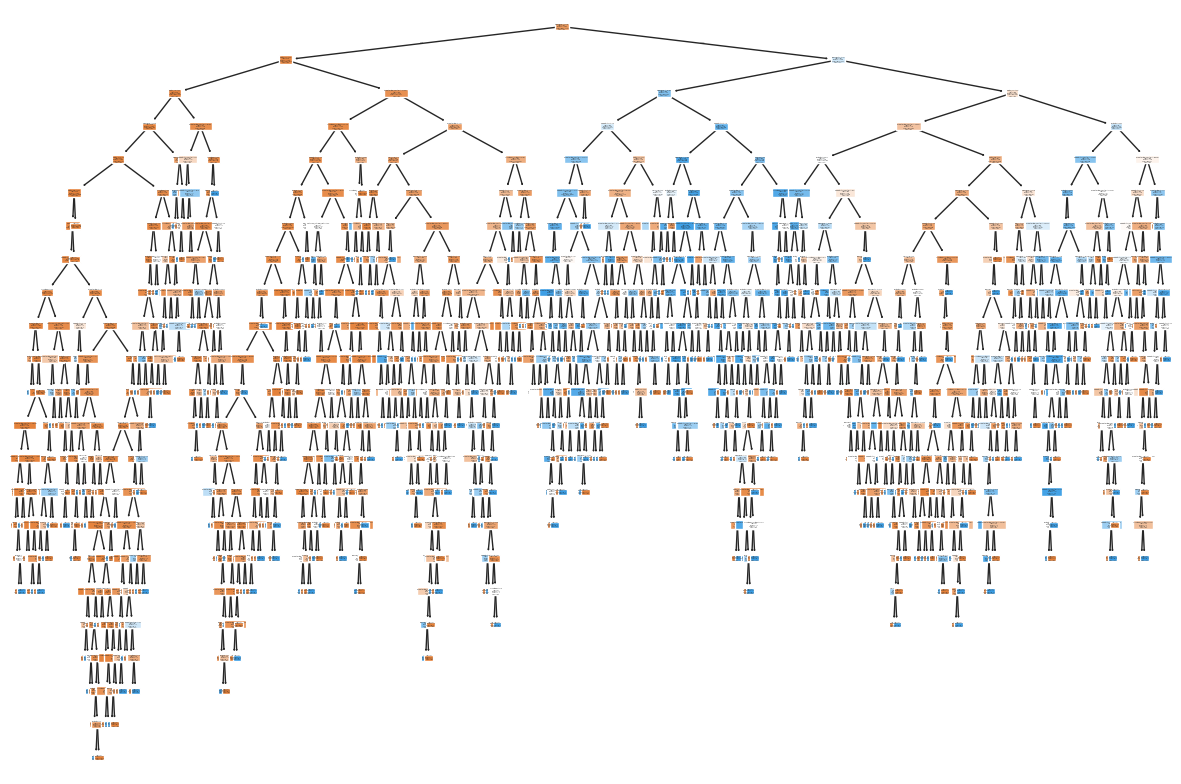

In [13]:
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["No","Yes"],
    filled=True
)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning — Pre-Pruning

Pre-pruning restricts tree growth during training. We use `GridSearchCV` with 5-fold cross-validation to tune two key parameters:

- **`max_depth`** — limits how deep the tree grows
- **`min_samples_leaf`** — minimum samples required at a leaf node

A `StandardScaler` is added inside the pipeline to ensure fair comparisons across splits.

In [14]:
#Pre-pruning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(
    [('Scaler',StandardScaler()),
    ('dt',DecisionTreeClassifier(class_weight="balanced"))])
param_grid = {"dt__max_depth":[2,3,4,5,6,7,8,9,10]}

classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)
classifierCV.fit(X_train,y_train)
y_pred = classifierCV.predict(X_test)
print(classifierCV.best_params_)
print("F1_Score:",f1_score(y_test,y_pred))

{'dt__max_depth': 2}
F1_Score: 0.676200204290092


#### Tuning `min_samples_leaf`

In [15]:
pipeline = Pipeline([('scalar',StandardScaler()),
                    ('dt',DecisionTreeClassifier(class_weight="balanced"))])
param_grid = {"dt__min_samples_leaf":[10,20,30,40,50,60,70]}

classifierCV=GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

classifierCV.fit(X_train,y_train)
y_pred = classifierCV.predict(X_test)
print(classifierCV.best_params_)
print("F1_score: ",f1_score(y_test,y_pred))


{'dt__min_samples_leaf': 70}
F1_score:  0.6450381679389313


### 6.1 Best Pre-Pruned Model

Applying the best parameters found: `max_depth=2`, `min_samples_leaf=40`.

F1_Score: 0.676200204290092


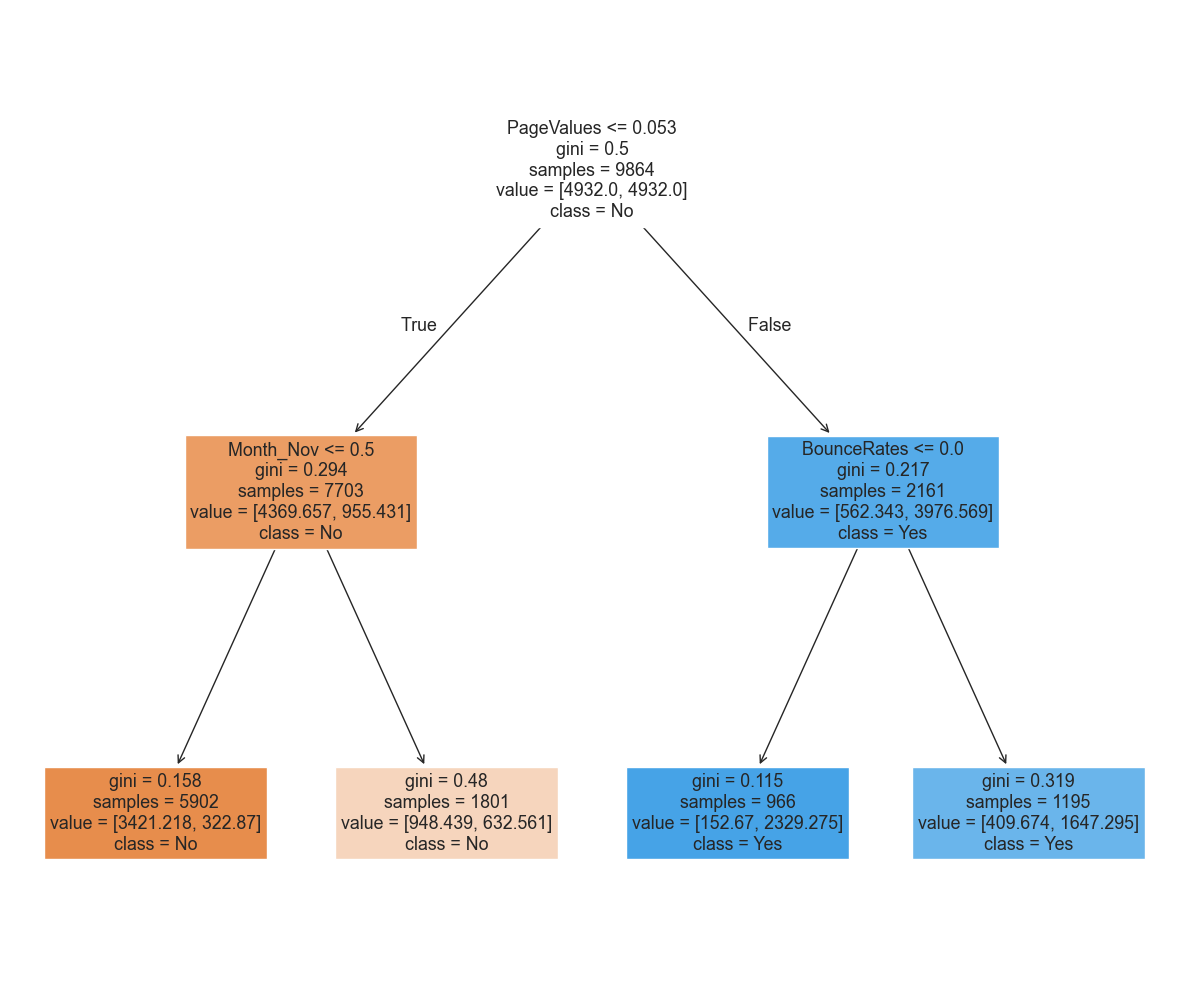

In [16]:
model = DecisionTreeClassifier(max_depth=2,min_samples_leaf=40,class_weight="balanced")
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("F1_Score:",f1_score(y_test,y_pred))

plt.figure(figsize=(12,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["No","Yes"],
    filled=True
)
plt.tight_layout()
plt.show()

## 7. Post-Pruning — Cost-Complexity Pruning (CCP)

Post-pruning trims an already-trained full tree. The key parameter `ccp_alpha` controls how aggressively branches are removed.

- A **higher alpha** removes more branches (simpler tree, less overfitting)
- A **lower alpha** keeps more branches (complex tree, more overfitting)

We compute the pruning path and use `GridSearchCV` to find the optimal alpha.

In [17]:
full_tree = DecisionTreeClassifier(class_weight="balanced")
full_tree.fit(X_train,y_train)

path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

pipeline = Pipeline([('scalar',StandardScaler()),
                     ('dt',DecisionTreeClassifier(class_weight="balanced"))])

param_grid = {"dt__ccp_alpha":ccp_alphas}
classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)
classifierCV.fit(X_train,y_train)
y_pred = classifierCV.predict(X_test)
print("Best params:",classifierCV.best_params_)
print("F1 Score:",f1_score(y_test,y_pred))

Best params: {'dt__ccp_alpha': np.float64(0.02220344288910653)}
F1 Score: 0.676200204290092


### 7.1 Best Post-Pruned Model

Applying the best `ccp_alpha` found from grid search.

F1 Score 0.676200204290092


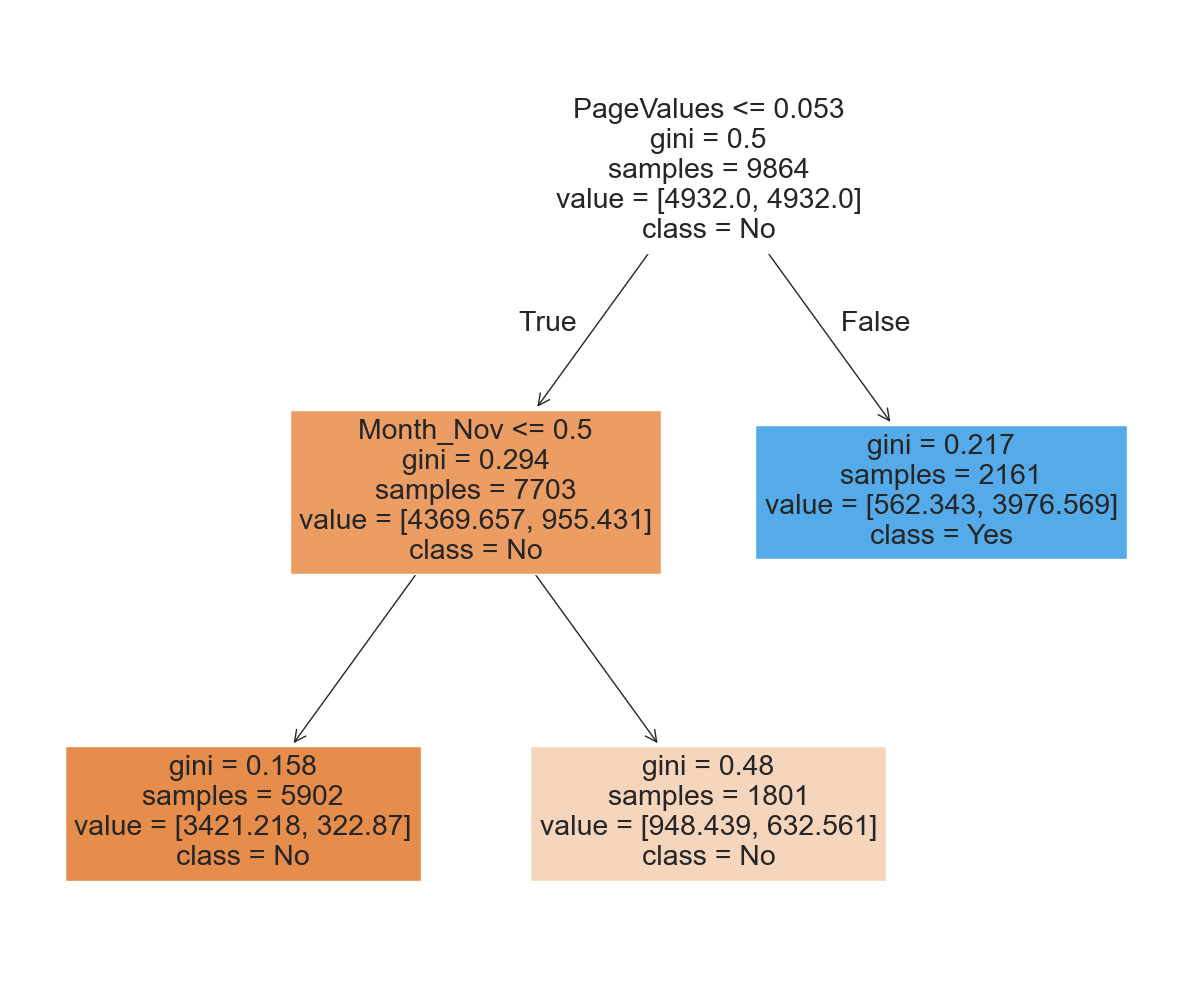

In [18]:
model = DecisionTreeClassifier(ccp_alpha=0.017785110000324428,class_weight="balanced")
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("F1 Score",f1_score(y_test,y_pred))

plt.figure(figsize=(12,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["No","Yes"],
    filled=True
)
plt.tight_layout()
plt.show()

## 8. Final Results & Summary

| Model | F1-Score |
|---|---|
| Baseline (Unpruned) | ~0.57 |
| Pre-Pruned (`max_depth=2`) | 0.676 |
| Post-Pruned (CCP) | 0.676 |

**Key Findings:**
- Both pruning techniques significantly improve F1-Score over the baseline.
- Pre-pruning and post-pruning reach similar performance (~67.6%), suggesting the optimal tree complexity has been found.
- The model successfully exceeds the 55% benchmark target.

**Visualisations below:** High-resolution tree diagram and performance comparison chart.

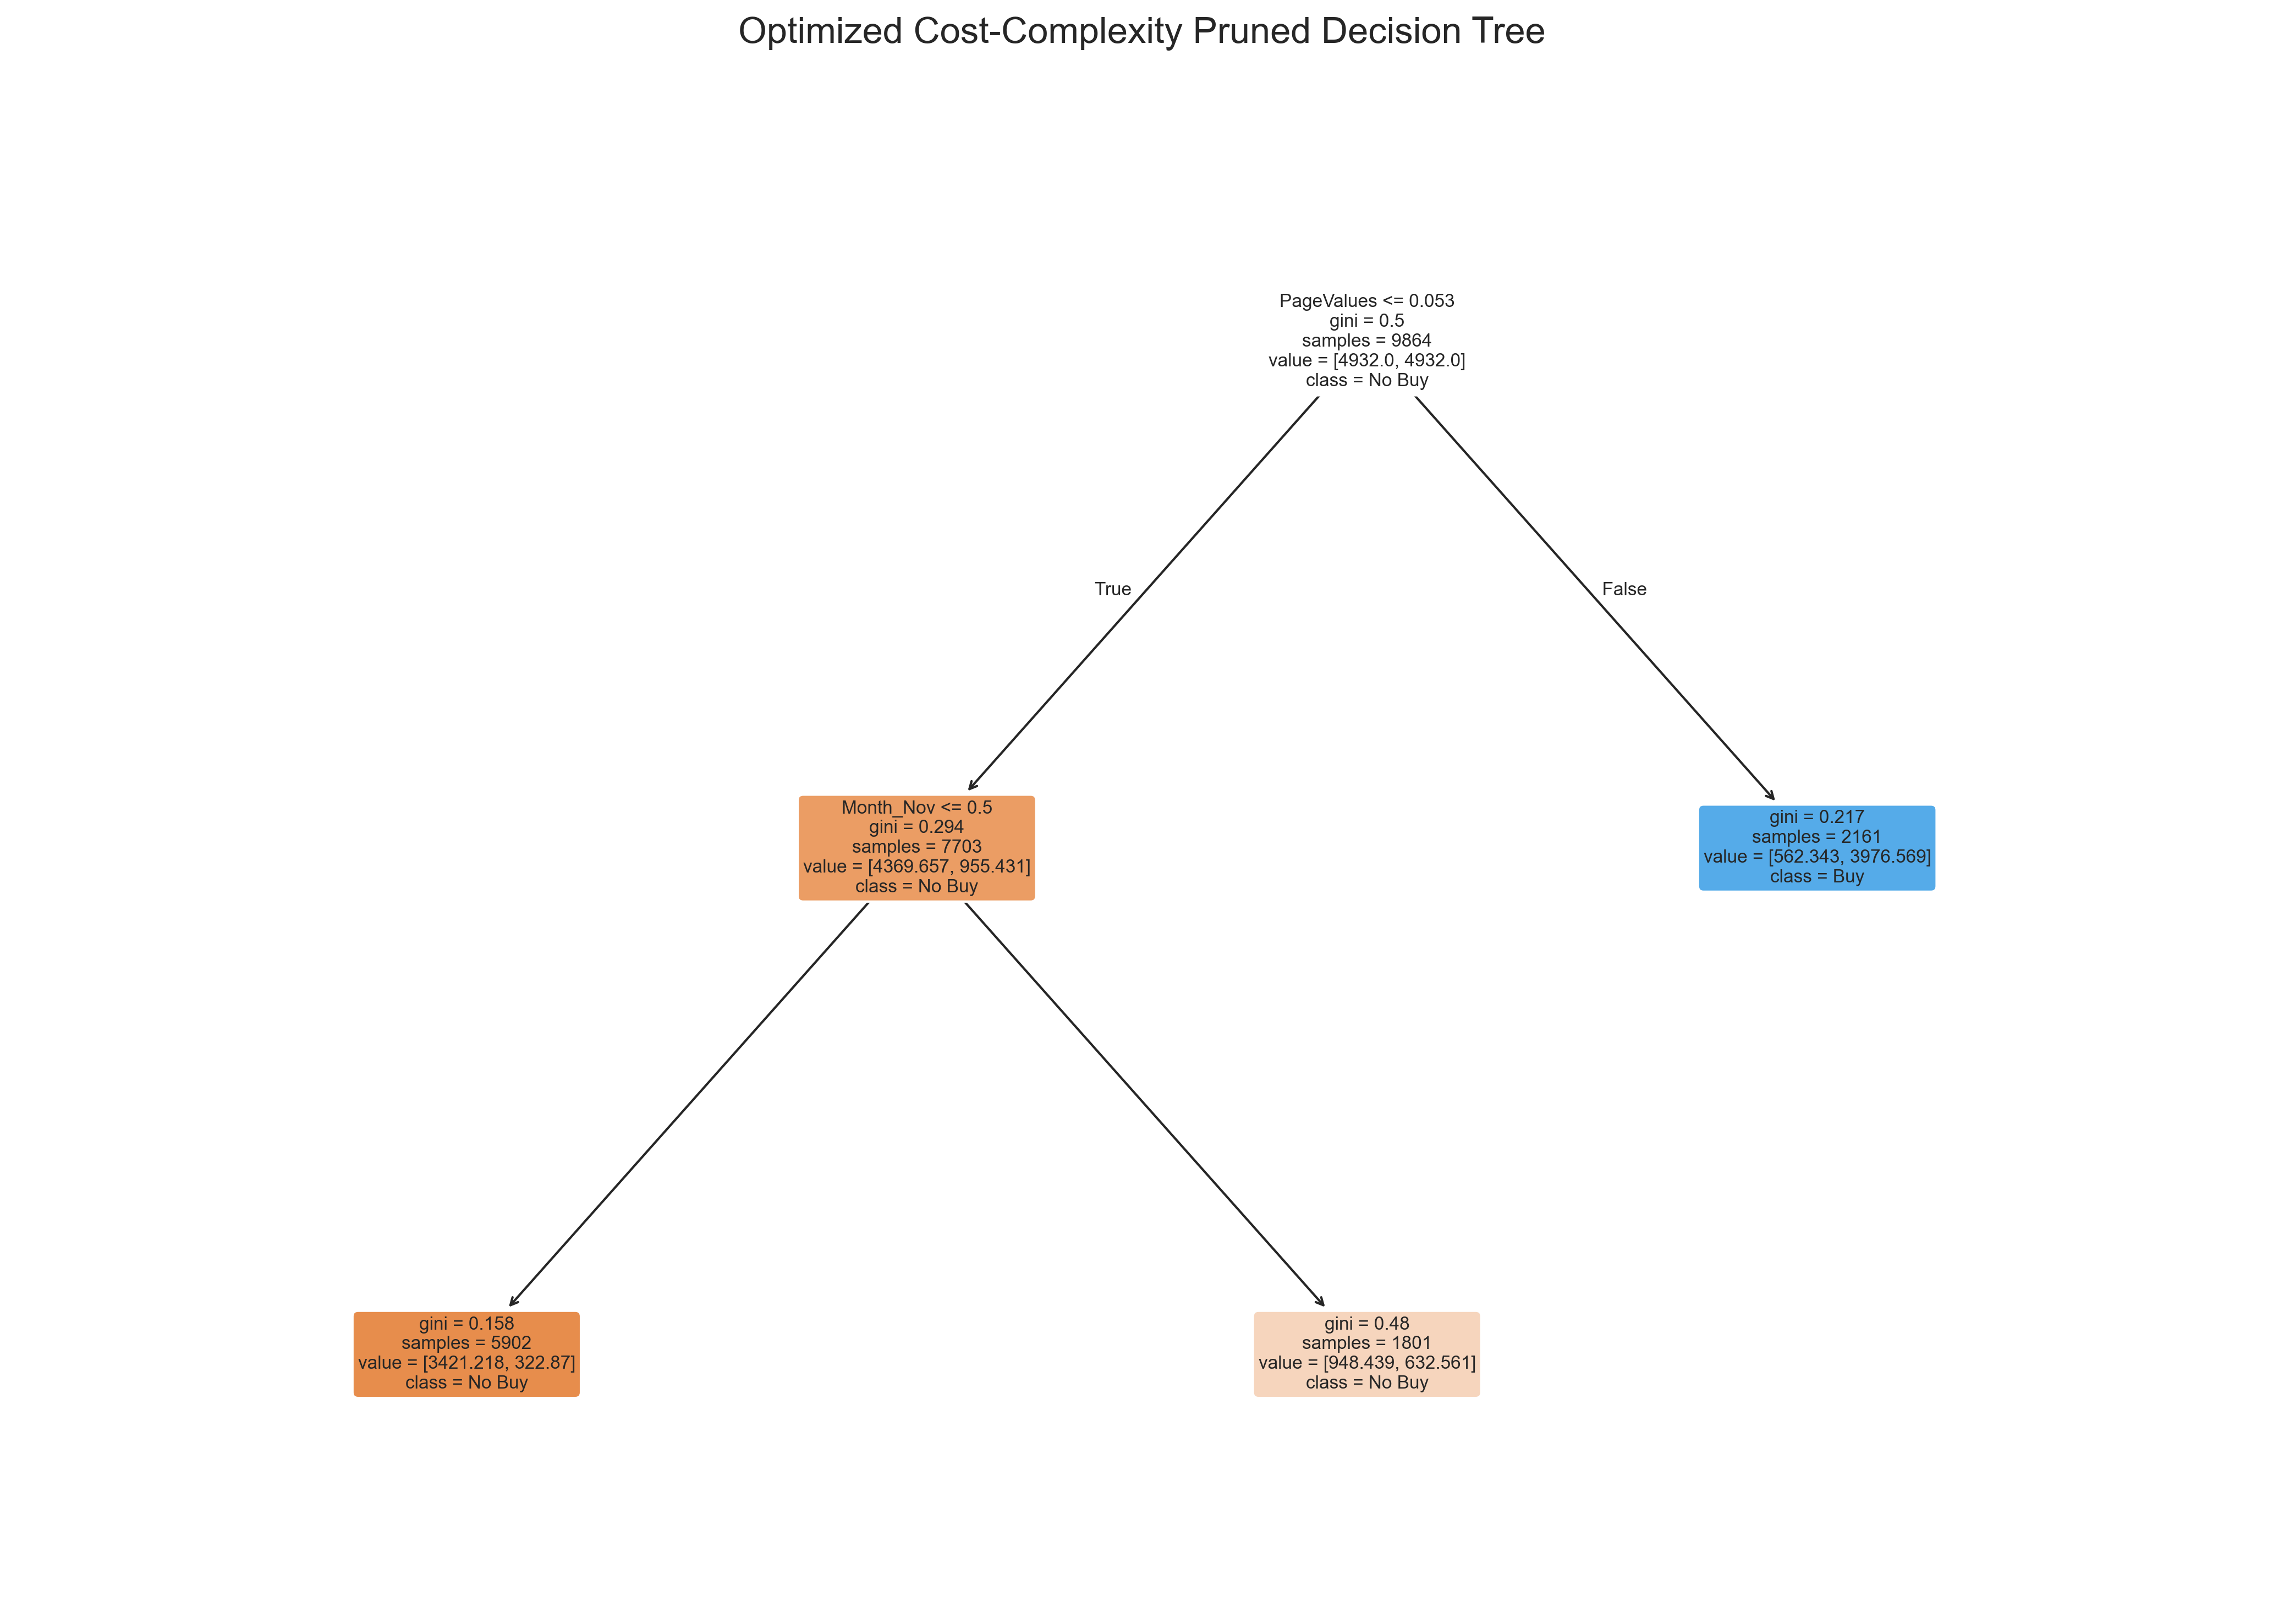

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a high-resolution figure canvas (300 DPI is print quality)
plt.figure(figsize=(14, 10), dpi=300)

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Buy", "Buy"],
    filled=True,
    rounded=True,  # Makes the node boxes look modern and rounded
    fontsize=8,  # Keeps text readable but small enough to fit
)

plt.title("Optimized Cost-Complexity Pruned Decision Tree", fontsize=16, pad=20)
plt.tight_layout()

# 💾 THIS LINE SAVES THE IMAGE TO YOUR COMPUTER
plt.savefig("pruned_decision_tree.png", bbox_inches="tight", dpi=300)
plt.show()


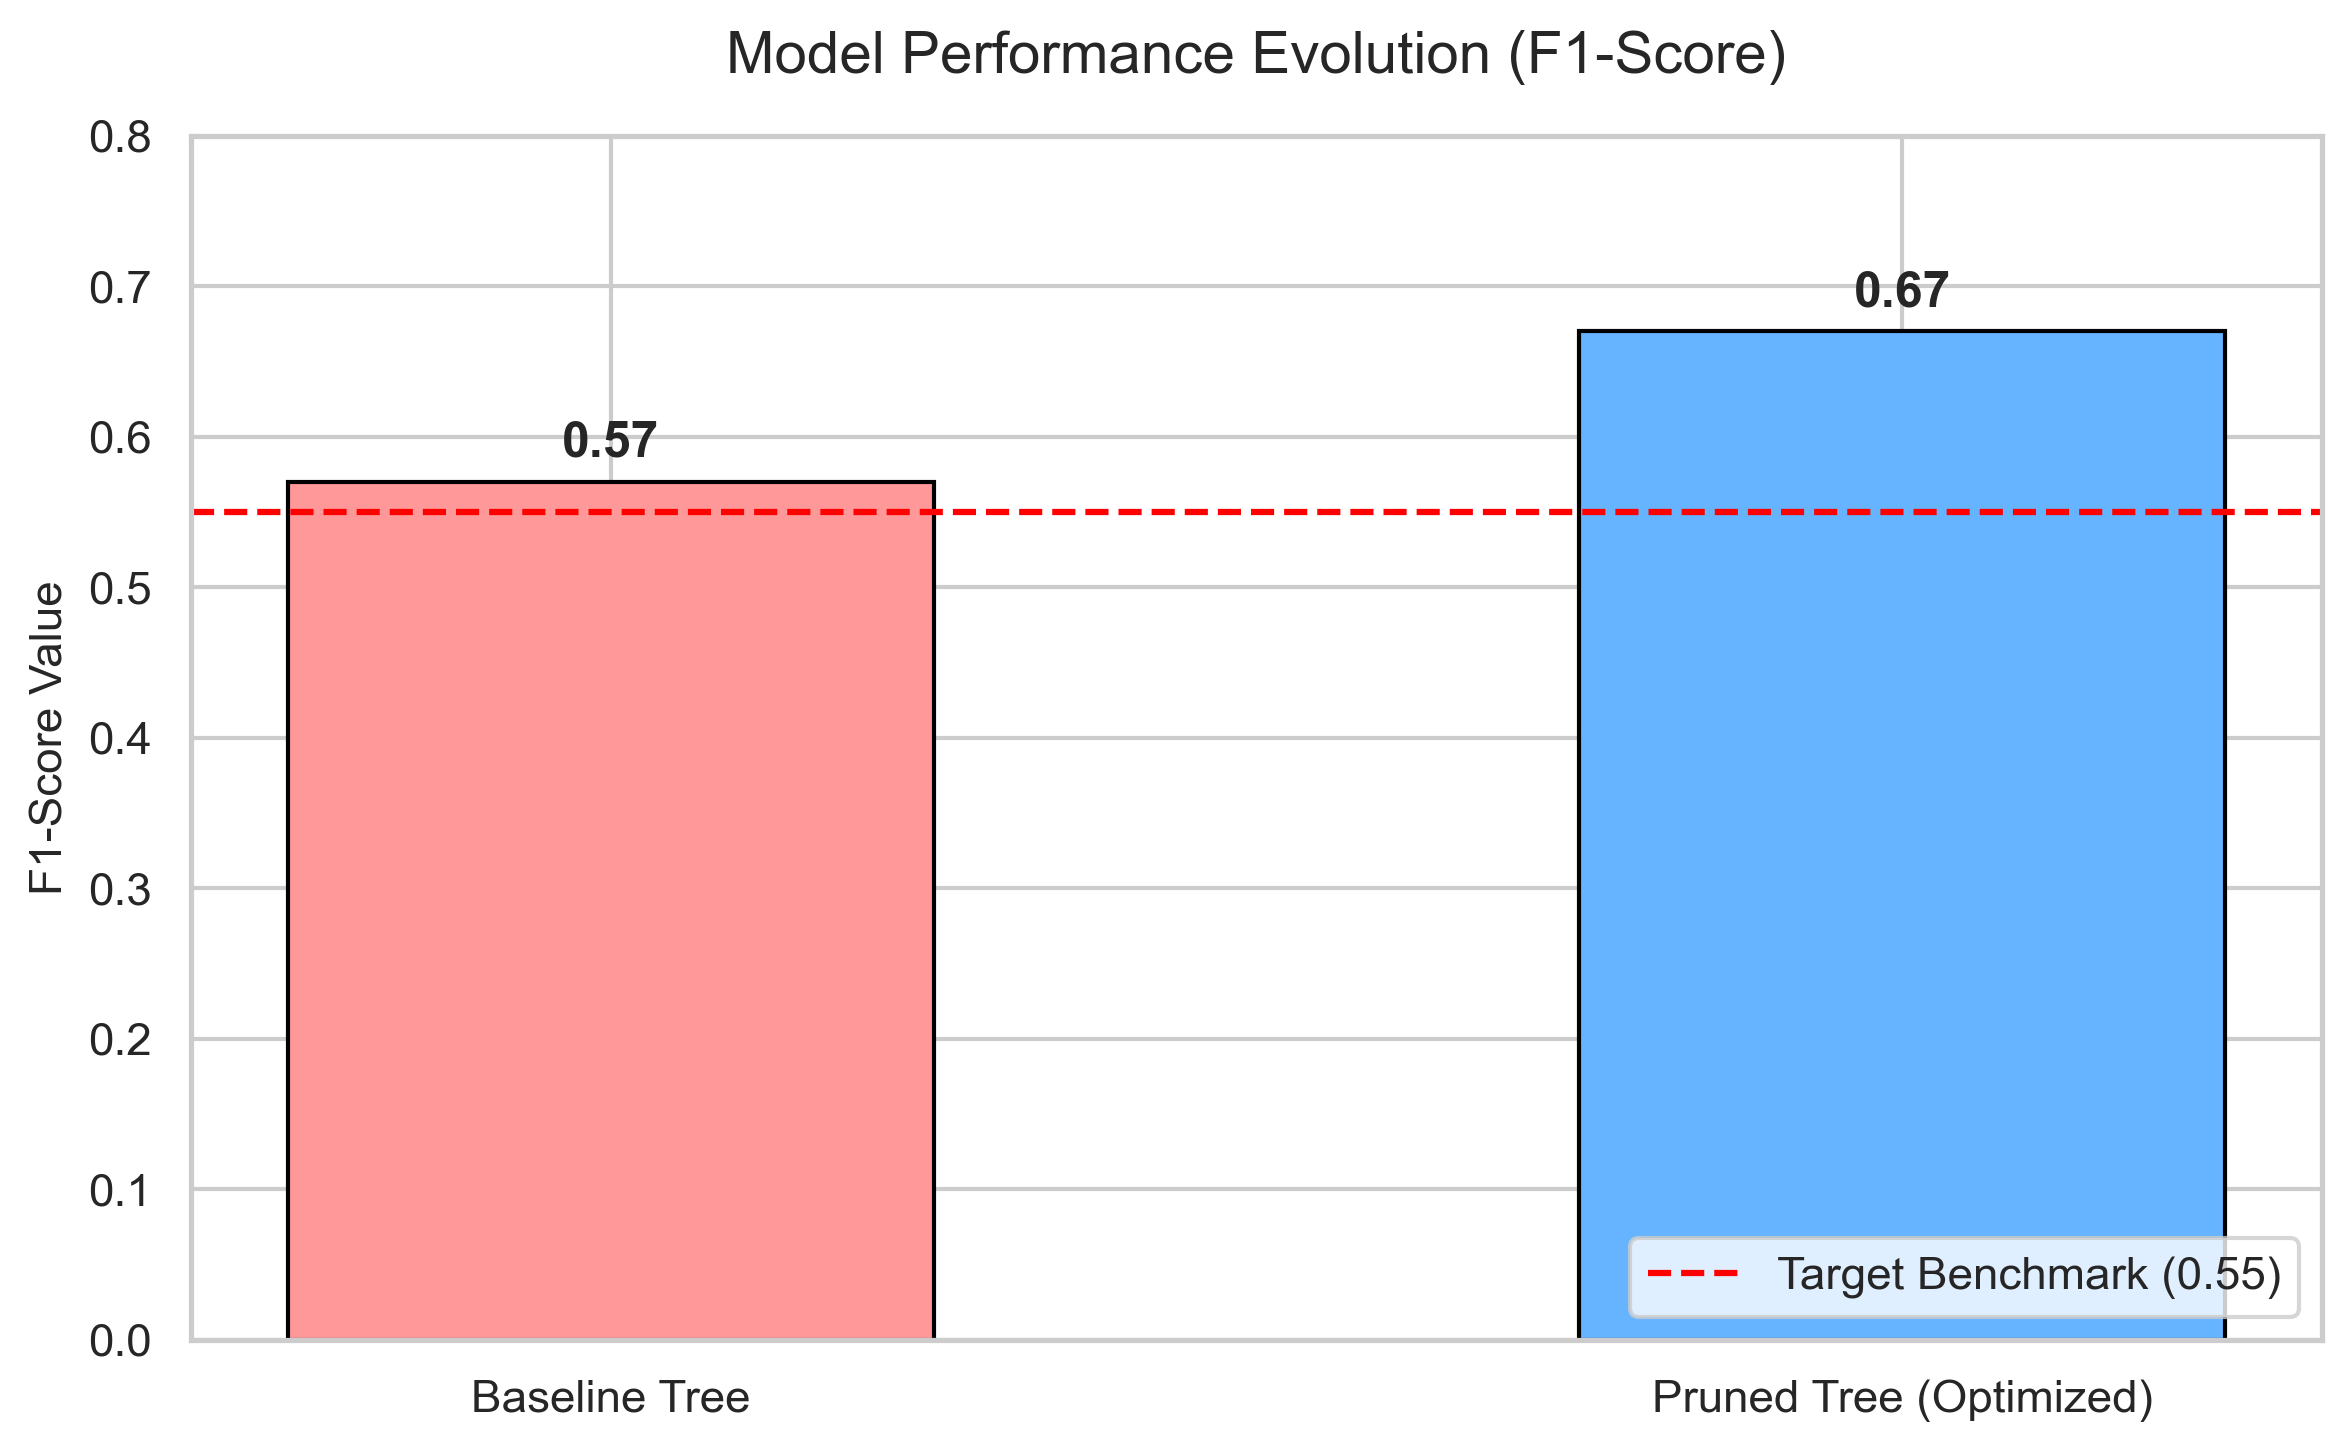

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for comparison
models = ["Baseline Tree", "Pruned Tree (Optimized)"]
f1_scores = [0.57, 0.67]  # Your actual before-and-after F1 scores
benchmarks = [0.55] * 2  # The assignment benchmark line

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5), dpi=300)

# Plot the bars
colors = ["#ff9999", "#66b3ff"]  # Soft red for baseline, professional blue for optimized
bars = plt.bar(models, f1_scores, color=colors, width=0.5, edgecolor="black")

# Add the target benchmark line
plt.axhline(
    y=0.55, color="red", linestyle="--", linewidth=1.5, label="Target Benchmark (0.55)"
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Formatting
plt.title("Model Performance Evolution (F1-Score)", fontsize=14, pad=15)
plt.ylabel("F1-Score Value", fontsize=11)
plt.ylim(0, 0.8)
plt.legend(loc="lower right")
plt.tight_layout()

# 💾 SAVE THE CHART
plt.savefig("model_performance_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
